         ts_s  loss_rate
0  1776702588   0.000000
1  1776702589   0.000000
2  1776702590   0.085221
3  1776702591   0.327671
4  1776702592   0.284375


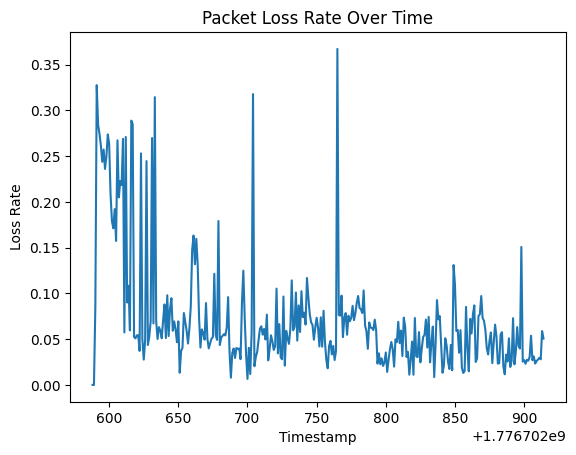

In [1]:
import pandas as pd

# Load the CSV
df = pd.read_csv("stats.csv")

# Compute loss rate: lost / (pkts + lost)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"])

# Group by timestamp and compute average loss rate
loss_rate_per_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

print(loss_rate_per_time.head())


loss_rate_per_time.to_csv("loss_rate_per_time.csv", index=False)

# Plot (optional)
import matplotlib.pyplot as plt
plt.plot(loss_rate_per_time["ts_s"], loss_rate_per_time["loss_rate"])
plt.xlabel("Timestamp")
plt.ylabel("Loss Rate")
plt.title("Packet Loss Rate Over Time")
plt.show()



# this zoom packet had the zoom running for some time 

Mode: Standard Video
Optimal Weights Found: Loss=0.7, FPS=0.1, Jitter=0.2
Maximum Model Accuracy: 75.27%


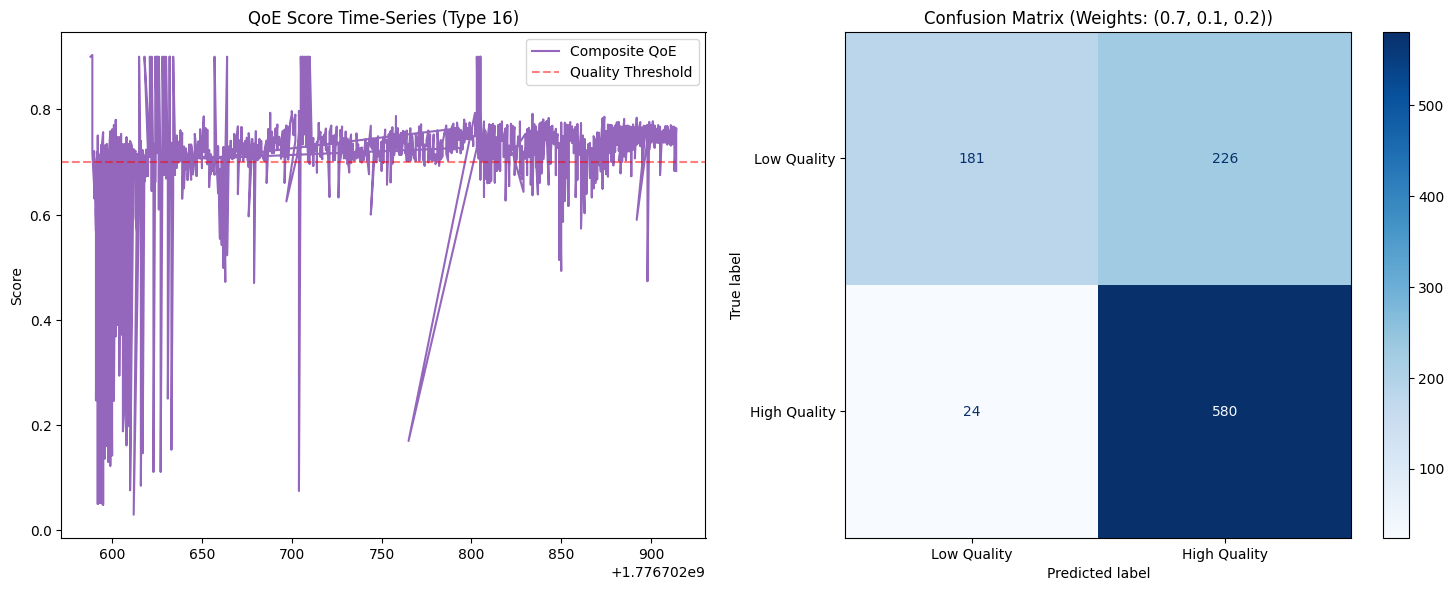


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Low Quality       0.88      0.44      0.59       407
High Quality       0.72      0.96      0.82       604

    accuracy                           0.75      1011
   macro avg       0.80      0.70      0.71      1011
weighted avg       0.79      0.75      0.73      1011



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from itertools import product

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. METRIC CALCULATION (Adaptive for Screenshare)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Detection of Screenshare (Media Type 13)
# Based on: https://dl.acm.org/doi/pdf/10.1145/3517745.3561414
df['is_screenshare'] = df['media_type'] == 13

# Apply conditional normalization targets
# Screenshare targets ~10 FPS; Video targets 30 FPS
df['fps_target'] = np.where(df['is_screenshare'], 10, 30)
df['fps_norm'] = (df['frames'] / df['fps_target']).clip(0, 1)

# Jitter threshold is 40ms for video, but often 60ms for screenshare
df['jitter_threshold'] = np.where(df['is_screenshare'], 60, 40)

if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000
    df['jitter_norm'] = (1 - (df['jitter_ms'] / df['jitter_threshold'])).clip(0, 1)

# 3. DEFINE GROUND TRUTH (The "Actual" Quality)
# Using your Stressed Network observations (Avg 7.48% loss mentioned in Overleaf)
df['actual_qoe_bin'] = np.where((df['loss_rate'] > 0.0748) | (df['frames'] < 5), 0, 1)

# 4. OPTIMIZATION: FIND BEST WEIGHTS
def calculate_accuracy(w1, w2, w3, data):
    # Dynamic calculation using the pre-normalized columns
    score = (w1 * (1 - data['loss_rate'])) + (w2 * data['fps_norm']) + (w3 * data['jitter_norm'])
    # Pred: 1 if Score > 0.7 (High), else 0 (Low)
    pred_bin = np.where(score > 0.7, 1, 0)
    return (pred_bin == data['actual_qoe_bin']).mean(), pred_bin

# Test combinations of weights that sum to 1.0
best_acc = 0
best_weights = (0.4, 0.3, 0.3)
weights_range = [np.round(x, 1) for x in np.linspace(0.1, 0.8, 8)]

for w1, w2 in product(weights_range, weights_range):
    w3 = np.round(1.0 - w1 - w2, 1)
    if w3 >= 0.1:
        acc, _ = calculate_accuracy(w1, w2, w3, df)
        if acc > best_acc:
            best_acc = acc
            best_weights = (w1, w2, w3)

print(f"Mode: {'Screen Share' if df['is_screenshare'].any() else 'Standard Video'}")
print(f"Optimal Weights Found: Loss={best_weights[0]}, FPS={best_weights[1]}, Jitter={best_weights[2]}")
print(f"Maximum Model Accuracy: {best_acc:.2%}")

# 5. GENERATE FINAL CONFUSION MATRIX
final_acc, y_pred = calculate_accuracy(*best_weights, df)
y_true = df['actual_qoe_bin']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Quality', 'High Quality'])

# 6. PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Optimized QoE over time
df['qoe_score'] = (best_weights[0] * (1 - df['loss_rate'])) + \
                  (best_weights[1] * df['fps_norm']) + \
                  (best_weights[2] * df['jitter_norm'])

ax1.plot(df['ts_s'], df['qoe_score'], color='#9467bd', label='Composite QoE')
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Quality Threshold')
ax1.set_title(f"QoE Score Time-Series (Type {'13' if df['is_screenshare'].any() else '16'})")
ax1.set_ylabel('Score')
ax1.legend()

# Plot Confusion Matrix
disp.plot(ax=ax2, cmap='Blues')
ax2.set_title(f'Confusion Matrix (Weights: {best_weights})')

plt.tight_layout()
plt.savefig('qoe_confusion_matrix_optimized.png')
plt.show()

# 7. SUMMARY
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Low Quality', 'High Quality']))